<a href="https://colab.research.google.com/github/Lyra0710/Blog-and-News-Website/blob/main/task_2_yelp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2 Yelp Polarity Sentiment Classification

In [1]:
!pip -q install datasets nltk scikit-learn seaborn

In [2]:
# Environment setup and reproducibility
import os
import re
import time
import json
import math
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
)

SEED = 2383

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


## 2.1 Data Preprocessing

### 1. Analyse review length distribution, class distribution and class balance.

In [3]:
# Load the Yelp Polarity dataset

dataset = load_dataset("fancyzhx/yelp_polarity")

print(dataset)
print(dataset["train"].features)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})
{'text': Value('string'), 'label': ClassLabel(names=['1', '2'])}
{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}


Dataset splits to pd df

In [4]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nFirst five training examples:")
display(train_df.head())

Training shape: (560000, 2)
Test shape: (38000, 2)

Columns: ['text', 'label']

First five training examples:


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


### 2. Handle missing values or malformed entries, if any

In [5]:
# Check the dataset

for name, df in [("Train", train_df), ("Test", test_df)]:
    print(f"\n{name} set shape:", df.shape)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nLabel counts:")
    print(df["label"].value_counts().sort_index())

    print("\nLabel proportions:")
    print(df["label"].value_counts(normalize=True).sort_index())

# Count words in each review
train_df["word_count"] = train_df["text"].str.split().str.len()
test_df["word_count"] = test_df["text"].str.split().str.len()

print("\nTraining review length:")
print(train_df["word_count"].describe())

print("\nTest review length:")
print(test_df["word_count"].describe())


Train set shape: (560000, 2)

Missing values:
text     0
label    0
dtype: int64

Duplicate rows: 0

Label counts:
label
0    280000
1    280000
Name: count, dtype: int64

Label proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Test set shape: (38000, 2)

Missing values:
text     0
label    0
dtype: int64

Duplicate rows: 0

Label counts:
label
0    19000
1    19000
Name: count, dtype: int64

Label proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Training review length:
count    560000.000000
mean        133.028873
std         122.611613
min           1.000000
25%          51.000000
50%          97.000000
75%         174.000000
max        1052.000000
Name: word_count, dtype: float64

Test review length:
count    38000.000000
mean       132.558632
std        121.216615
min          1.000000
25%         51.000000
50%         97.000000
75%        173.000000
max       1007.000000
Name: word_count, dtype: float64


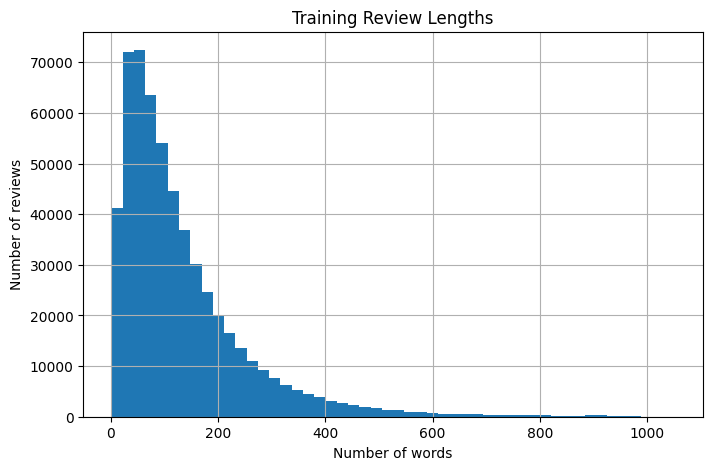

In [6]:
# Plot review lengths

train_df["word_count"].hist(bins=50, figsize=(8, 5))

plt.title("Training Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.show()

Validation Split

In [7]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_df.shape)

Training set: (504000, 3)
Validation set: (56000, 3)
Test set: (38000, 3)


### 3. Perform text preprocessing, including but not limited to:
* lowercasing
* removal of punctuation and special characters
* stopword removal
* stemming or lemmatization (if applicable)

In [8]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Keep negation words because they affect sentiment
stop_words = stop_words - {"no", "not", "nor", "never"}

stemmer = PorterStemmer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)


train_data["clean_text"] = train_data["text"].apply(preprocess_text)
val_data["clean_text"] = val_data["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

print("Original review:")
print(train_data.iloc[0]["text"])

print("\nProcessed review:")
print(train_data.iloc[0]["clean_text"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original review:
I haven't been here in a while.  Stopped in Monday AM and didn't have to wait for a table which is rare.  I had their special which was scrambled eggs with apple sausage and spinach.  Served with hash browns and toast it was a great way to start the day.

Processed review:
stop monday wait tabl rare special scrambl egg appl sausag spinach serv hash brown toast great way start day


### 4. Tokenise the processed text.

In [9]:
train_data["processed_length"] = train_data["clean_text"].str.split().str.len()

print(train_data["processed_length"].describe())

for length in [128, 200, 256, 300]:
    percentage_kept = (
        train_data["processed_length"] <= length
    ).mean() * 100

    print(f"{length} tokens: {percentage_kept:.2f}% of reviews fit")

count    504000.000000
mean         69.934214
std          64.277509
min           0.000000
25%          27.000000
50%          51.000000
75%          91.000000
max         980.000000
Name: processed_length, dtype: float64
128 tokens: 86.46% of reviews fit
200 tokens: 95.37% of reviews fit
256 tokens: 97.84% of reviews fit
300 tokens: 98.75% of reviews fit


In [10]:
word_counts = Counter()

for text in train_data["clean_text"]:
    word_counts.update(text.split())

total_tokens = sum(word_counts.values())

for size in [10000, 30000, 50000, 100000]:
    kept_tokens = sum(
        count for _, count in word_counts.most_common(size)
    )

    coverage = kept_tokens / total_tokens * 100

    print(f"{size:,} words keep {coverage:.2f}% of all tokens")

print("\nUnique words:", len(word_counts))

10,000 words keep 97.39% of all tokens
30,000 words keep 99.29% of all tokens
50,000 words keep 99.61% of all tokens
100,000 words keep 99.85% of all tokens

Unique words: 152030


Based on the above, we define the settings as follows:

In [11]:
MAX_LENGTH = 256
MAX_VOCAB_SIZE = 30000

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

# Replace empty processed reviews
for df in [train_data, val_data, test_df]:
    df.loc[df["clean_text"] == "", "clean_text"] = UNK_TOKEN

# Count words in the training split only
word_counts = Counter()

for text in train_data["clean_text"]:
    word_counts.update(text.split())

# Create the vocabulary
vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, count in word_counts.most_common():
    if word not in vocab:
        vocab[word] = len(vocab)

    if len(vocab) == MAX_VOCAB_SIZE:
        break

print("Vocabulary size:", len(vocab))
print("Padding token ID:", vocab[PAD_TOKEN])
print("Unknown token ID:", vocab[UNK_TOKEN])

Vocabulary size: 30000
Padding token ID: 0
Unknown token ID: 1


Tokenizer Function

In [12]:
PAD_INDEX = vocab[PAD_TOKEN]
UNK_INDEX = vocab[UNK_TOKEN]


def tokenize_text(text):
    words = text.split()

    token_ids = [
        vocab.get(word, UNK_INDEX)
        for word in words
    ]

    token_ids = token_ids[:MAX_LENGTH]

    padding_needed = MAX_LENGTH - len(token_ids)
    token_ids += [PAD_INDEX] * padding_needed

    return token_ids

In [13]:
example_text = train_data.iloc[0]["clean_text"]
example_ids = tokenize_text(example_text)

print("First 20 token IDs:")
print(example_ids[:20])

print("\nSequence length:", len(example_ids))

First 20 token IDs:
[198, 1042, 27, 47, 654, 167, 1877, 283, 1000, 726, 1051, 119, 1220, 826, 674, 14, 59, 148, 50, 0]

Sequence length: 256


#### Create PyTorch datasets from tokenized reviews

In [14]:
class YelpDataset(Dataset):
    def __init__(self, data):
        self.texts = data["clean_text"].tolist()
        self.labels = data["label"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        token_ids = tokenize_text(self.texts[index])
        label = self.labels[index]

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [15]:
train_dataset = YelpDataset(train_data)
val_dataset = YelpDataset(val_data)
test_dataset = YelpDataset(test_df)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Training examples: 504000
Validation examples: 56000
Test examples: 38000


In [16]:
sample_tokens, sample_label = train_dataset[0]

print("Token tensor shape:", sample_tokens.shape)
print("Label:", sample_label)

Token tensor shape: torch.Size([256])
Label: tensor(1.)


### 5. Create textual embeddings learned from scratch.

#### Model 1: Baseline Model - Max-pooling embedding classifier

In [17]:
EMBEDDING_DIM = 128


class MaxPoolingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, padding_index):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_index
        )

        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)

        padding_mask = token_ids == PAD_INDEX
        embeddings = embeddings.masked_fill(
            padding_mask.unsqueeze(-1),
            float("-inf")
        )

        pooled_embeddings = embeddings.max(dim=1).values

        logits = self.classifier(pooled_embeddings).squeeze(1)

        return logits

In [18]:
model_1 = MaxPoolingClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    padding_index=PAD_INDEX
).to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model_1.parameters()
)

print("Model 1 parameter count:", parameter_count)

Model 1 parameter count: 3840129


#### Model 2: Experimental Model - Unidirectional LSTM classifier

In [19]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        padding_index
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_index
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)

        lstm_outputs, _ = self.lstm(embeddings)

        lengths = (token_ids != PAD_INDEX).sum(dim=1)
        last_index = lengths - 1

        batch_index = torch.arange(
            token_ids.size(0),
            device=token_ids.device
        )

        final_outputs = lstm_outputs[batch_index, last_index]

        return self.classifier(final_outputs).squeeze(1)

#### Model 3: Experimental Model - Transformer encoder classifier

In [20]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_heads,
        num_layers,
        feedforward_dim,
        dropout,
        max_length,
        padding_index
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_index
        )

        self.position_embedding = nn.Embedding(
            max_length,
            embedding_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=feedforward_dim,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, token_ids):
        sequence_length = token_ids.size(1)

        positions = torch.arange(
            sequence_length,
            device=token_ids.device
        ).unsqueeze(0)

        embeddings = (
            self.token_embedding(token_ids)
            + self.position_embedding(positions)
        )

        padding_mask = token_ids == PAD_INDEX

        encoded_tokens = self.encoder(
            embeddings,
            src_key_padding_mask=padding_mask
        )

        valid_tokens = (~padding_mask).unsqueeze(-1)

        pooled_embeddings = (
            encoded_tokens * valid_tokens
        ).sum(dim=1) / valid_tokens.sum(dim=1).clamp(min=1)

        return self.classifier(pooled_embeddings).squeeze(1)

## 2.2 Model Training and Evaluation


In [21]:
def train_model(
    model,
    optimizer,
    loss_function,
    train_loader,
    val_loader,
    model_name,
    max_epochs,
    patience
):
    artifact_dir = Path("training_artifacts")
    artifact_dir.mkdir(exist_ok=True)

    run_id = time.strftime("%Y%m%d_%H%M%S")

    log_path = artifact_dir / f"{model_name}_{run_id}_training_log.jsonl"
    checkpoint_path = artifact_dir / f"{model_name}_{run_id}_best.pt"
    metadata_path = artifact_dir / f"{model_name}_{run_id}_metadata.json"

    history = []
    best_validation_f1 = -float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    training_start_time = time.time()

    for epoch in range(max_epochs):
        model.train()
        total_training_loss = 0.0

        for batch_number, (token_ids, labels) in enumerate(train_loader):
            token_ids = token_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            logits = model(token_ids)
            loss = loss_function(logits, labels)

            loss.backward()
            optimizer.step()

            total_training_loss += loss.item() * labels.size(0)

            if (batch_number + 1) % 500 == 0:
                print(
                    f"Epoch {epoch + 1}, "
                    f"batch {batch_number + 1}/{len(train_loader)}, "
                    f"loss: {loss.item():.4f}"
                )

        training_loss = total_training_loss / len(train_loader.dataset)

        model.eval()
        total_validation_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        validation_labels = []
        validation_predictions = []

        with torch.no_grad():
            for token_ids, labels in val_loader:
                token_ids = token_ids.to(DEVICE)
                labels = labels.to(DEVICE)

                logits = model(token_ids)
                loss = loss_function(logits, labels)

                total_validation_loss += loss.item() * labels.size(0)

                predictions = (torch.sigmoid(logits) >= 0.5).long()

                correct_predictions += (
                    predictions == labels.long()
                ).sum().item()

                total_predictions += labels.size(0)

                validation_labels.extend(labels.cpu().numpy())
                validation_predictions.extend(predictions.cpu().numpy())

        validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = correct_predictions / total_predictions

        _, _, validation_macro_f1, _ = (
            precision_recall_fscore_support(
                validation_labels,
                validation_predictions,
                average="macro",
                zero_division=0
            )
        )

        epoch_result = {
            "epoch": epoch + 1,
            "training_loss": training_loss,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_macro_f1
        }

        history.append(epoch_result)

        with log_path.open("a") as log_file:
            log_file.write(json.dumps(epoch_result) + "\n")

        print(
            f"\nEpoch {epoch + 1} complete | "
            f"train loss: {training_loss:.4f} | "
            f"validation loss: {validation_loss:.4f} | "
            f"validation accuracy: {validation_accuracy:.4f} | "
            f"validation macro-F1: {validation_macro_f1:.4f}\n"
        )

        if validation_macro_f1 > best_validation_f1:
            best_validation_f1 = validation_macro_f1

            best_model_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

            torch.save(
                {
                    "model_state_dict": best_model_state,
                    "vocab": vocab,
                    "max_length": MAX_LENGTH,
                    "best_epoch": epoch + 1
                },
                checkpoint_path
            )

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping after {epoch + 1} epochs.")
            break

    model.load_state_dict(best_model_state)

    training_time = time.time() - training_start_time
    epochs_completed = len(history)

    if DEVICE.type == "cuda":
        peak_memory_mb = (
            torch.cuda.max_memory_allocated() / (1024 ** 2)
        )
    else:
        peak_memory_mb = None

    metadata = {
        "model_name": model_name,
        "best_epoch": max(
            history,
            key=lambda result: result["validation_macro_f1"]
        )["epoch"],
        "best_validation_macro_f1": best_validation_f1,
        "epochs_completed": epochs_completed,
        "training_time_seconds": training_time,
        "examples_per_second": (
            len(train_loader.dataset) * epochs_completed
        ) / training_time,
        "peak_gpu_memory_mb": peak_memory_mb,
        "parameter_count": sum(
            parameter.numel()
            for parameter in model.parameters()
        )
    }

    with metadata_path.open("w") as metadata_file:
        json.dump(metadata, metadata_file, indent=2)

    print("Best validation macro-F1:", best_validation_f1)
    print("Best epoch:", metadata["best_epoch"])
    print("Epochs completed:", epochs_completed)
    print("Training time (seconds):", training_time)
    print("Examples per second:", metadata["examples_per_second"])
    print("Peak GPU memory (MB):", peak_memory_mb)

    return history, metadata

###  Baseline Model: Training settings

In [22]:
LSTM_HIDDEN_DIM = EMBEDDING_DIM

TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_NUM_LAYERS = 2
TRANSFORMER_FEEDFORWARD_DIM = 256
TRANSFORMER_DROPOUT = 0.2

assert EMBEDDING_DIM % TRANSFORMER_NUM_HEADS == 0

print("LSTM hidden size:", LSTM_HIDDEN_DIM)
print("Transformer head size:",
      EMBEDDING_DIM // TRANSFORMER_NUM_HEADS)
print("Transformer layers:", TRANSFORMER_NUM_LAYERS)
print("Transformer feed-forward size:",
      TRANSFORMER_FEEDFORWARD_DIM)

LSTM hidden size: 128
Transformer head size: 32
Transformer layers: 2
Transformer feed-forward size: 256


Dataloaders

In [23]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 7875
Validation batches: 875
Test batches: 594


In [24]:
MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

MODEL_1_LEARNING_RATE = 1e-3
MODEL_1_WEIGHT_DECAY = 1e-5

loss_function = nn.BCEWithLogitsLoss()

optimizer_1 = torch.optim.AdamW(
    model_1.parameters(),
    lr=MODEL_1_LEARNING_RATE,
    weight_decay=MODEL_1_WEIGHT_DECAY
)

In [25]:
model_1_history, model_1_metadata = train_model(
    model=model_1,
    optimizer=optimizer_1,
    loss_function=loss_function,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="baseline_max_pool",
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

Epoch 1, batch 500/7875, loss: 0.5616
Epoch 1, batch 1000/7875, loss: 0.4053
Epoch 1, batch 1500/7875, loss: 0.4256
Epoch 1, batch 2000/7875, loss: 0.2290
Epoch 1, batch 2500/7875, loss: 0.2290
Epoch 1, batch 3000/7875, loss: 0.1616
Epoch 1, batch 3500/7875, loss: 0.1786
Epoch 1, batch 4000/7875, loss: 0.1962
Epoch 1, batch 4500/7875, loss: 0.2841
Epoch 1, batch 5000/7875, loss: 0.3553
Epoch 1, batch 5500/7875, loss: 0.1977
Epoch 1, batch 6000/7875, loss: 0.2035
Epoch 1, batch 6500/7875, loss: 0.3524
Epoch 1, batch 7000/7875, loss: 0.2980
Epoch 1, batch 7500/7875, loss: 0.3841

Epoch 1 complete | train loss: 0.2919 | validation loss: 0.2145 | validation accuracy: 0.9125 | validation macro-F1: 0.9125

Epoch 2, batch 500/7875, loss: 0.1719
Epoch 2, batch 1000/7875, loss: 0.0974
Epoch 2, batch 1500/7875, loss: 0.2757
Epoch 2, batch 2000/7875, loss: 0.1710
Epoch 2, batch 2500/7875, loss: 0.2341
Epoch 2, batch 3000/7875, loss: 0.1779
Epoch 2, batch 3500/7875, loss: 0.1670
Epoch 2, batch 400

### Experimental Model 1: Unidirectional LSTM

In [26]:
MODEL_2_LEARNING_RATE = MODEL_1_LEARNING_RATE
MODEL_2_WEIGHT_DECAY = MODEL_1_WEIGHT_DECAY

model_2 = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=LSTM_HIDDEN_DIM,
    padding_index=PAD_INDEX
).to(DEVICE)

print(
    "Model 2 parameter count:",
    sum(parameter.numel() for parameter in model_2.parameters())
)

optimizer_2 = torch.optim.AdamW(
    model_2.parameters(),
    lr=MODEL_2_LEARNING_RATE,
    weight_decay=MODEL_2_WEIGHT_DECAY
)

model_2_history, model_2_metadata = train_model(
    model=model_2,
    optimizer=optimizer_2,
    loss_function=loss_function,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="unidirectional_lstm",
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

Model 2 parameter count: 3972225
Epoch 1, batch 500/7875, loss: 0.3090
Epoch 1, batch 1000/7875, loss: 0.1883
Epoch 1, batch 1500/7875, loss: 0.1963
Epoch 1, batch 2000/7875, loss: 0.2447
Epoch 1, batch 2500/7875, loss: 0.2529
Epoch 1, batch 3000/7875, loss: 0.2330
Epoch 1, batch 3500/7875, loss: 0.2412
Epoch 1, batch 4000/7875, loss: 0.2139
Epoch 1, batch 4500/7875, loss: 0.2158
Epoch 1, batch 5000/7875, loss: 0.1983
Epoch 1, batch 5500/7875, loss: 0.0547
Epoch 1, batch 6000/7875, loss: 0.3295
Epoch 1, batch 6500/7875, loss: 0.1224
Epoch 1, batch 7000/7875, loss: 0.1601
Epoch 1, batch 7500/7875, loss: 0.0937

Epoch 1 complete | train loss: 0.2180 | validation loss: 0.1680 | validation accuracy: 0.9361 | validation macro-F1: 0.9361

Epoch 2, batch 500/7875, loss: 0.1130
Epoch 2, batch 1000/7875, loss: 0.1139
Epoch 2, batch 1500/7875, loss: 0.1262
Epoch 2, batch 2000/7875, loss: 0.1357
Epoch 2, batch 2500/7875, loss: 0.1600
Epoch 2, batch 3000/7875, loss: 0.1626
Epoch 2, batch 3500/7875

### Experimental Model 2: Transformer encoder

In [27]:
MODEL_3_LEARNING_RATE = MODEL_1_LEARNING_RATE
MODEL_3_WEIGHT_DECAY = MODEL_1_WEIGHT_DECAY

model_3 = TransformerClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    num_heads=TRANSFORMER_NUM_HEADS,
    num_layers=TRANSFORMER_NUM_LAYERS,
    feedforward_dim=TRANSFORMER_FEEDFORWARD_DIM,
    dropout=TRANSFORMER_DROPOUT,
    max_length=MAX_LENGTH,
    padding_index=PAD_INDEX
).to(DEVICE)

print(
    "Model 3 parameter count:",
    sum(parameter.numel() for parameter in model_3.parameters())
)

optimizer_3 = torch.optim.AdamW(
    model_3.parameters(),
    lr=MODEL_3_LEARNING_RATE,
    weight_decay=MODEL_3_WEIGHT_DECAY
)

model_3_history, model_3_metadata = train_model(
    model=model_3,
    optimizer=optimizer_3,
    loss_function=loss_function,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="transformer_encoder",
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

Model 3 parameter count: 4137857
Epoch 1, batch 500/7875, loss: 0.2379
Epoch 1, batch 1000/7875, loss: 0.1721
Epoch 1, batch 1500/7875, loss: 0.2477
Epoch 1, batch 2000/7875, loss: 0.1854
Epoch 1, batch 2500/7875, loss: 0.2127
Epoch 1, batch 3000/7875, loss: 0.0681
Epoch 1, batch 3500/7875, loss: 0.2344
Epoch 1, batch 4000/7875, loss: 0.1413
Epoch 1, batch 4500/7875, loss: 0.1754
Epoch 1, batch 5000/7875, loss: 0.1835
Epoch 1, batch 5500/7875, loss: 0.1703
Epoch 1, batch 6000/7875, loss: 0.1993
Epoch 1, batch 6500/7875, loss: 0.1418
Epoch 1, batch 7000/7875, loss: 0.1380
Epoch 1, batch 7500/7875, loss: 0.1925


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Epoch 1 complete | train loss: 0.2193 | validation loss: 0.1878 | validation accuracy: 0.9247 | validation macro-F1: 0.9247

Epoch 2, batch 500/7875, loss: 0.1418
Epoch 2, batch 1000/7875, loss: 0.3125
Epoch 2, batch 1500/7875, loss: 0.1914
Epoch 2, batch 2000/7875, loss: 0.1532
Epoch 2, batch 2500/7875, loss: 0.1326
Epoch 2, batch 3000/7875, loss: 0.1242
Epoch 2, batch 3500/7875, loss: 0.1447
Epoch 2, batch 4000/7875, loss: 0.1227
Epoch 2, batch 4500/7875, loss: 0.2158
Epoch 2, batch 5000/7875, loss: 0.2085
Epoch 2, batch 5500/7875, loss: 0.2859
Epoch 2, batch 6000/7875, loss: 0.3080
Epoch 2, batch 6500/7875, loss: 0.2269
Epoch 2, batch 7000/7875, loss: 0.1254
Epoch 2, batch 7500/7875, loss: 0.1551

Epoch 2 complete | train loss: 0.1764 | validation loss: 0.1989 | validation accuracy: 0.9224 | validation macro-F1: 0.9223

Epoch 3, batch 500/7875, loss: 0.2115
Epoch 3, batch 1000/7875, loss: 0.1480
Epoch 3, batch 1500/7875, loss: 0.1599
Epoch 3, batch 2000/7875, loss: 0.1788
Epoch 3, 

Downloading from colab files

In [28]:
import shutil
from google.colab import files

shutil.make_archive(
    "training_artifacts",
    "zip",
    "training_artifacts"
)

files.download("training_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>